# Revela — XGBoost Risk Classifier

Trains a binary risk classifier on the ДЗК + ДРПП registry data.
Labels come from the rule engine: any tax ID with at least one discrepancy is `risk=1`.

**Goal**: learn to score *new* OTG datasets where the rules haven't been tuned,
and discover signal the rules might miss.

Put the raw xlsx files in `data/` before running:
- `data/land.xlsx`
- `data/estate.xlsx`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded')

Libraries loaded


## 1. Load data

In [2]:
land_raw = pd.read_excel('data/land.xlsx')
estate_raw = pd.read_excel('data/estate.xlsx')

print(f'Land:   {len(land_raw):,} rows, {land_raw.shape[1]} cols')
print(f'Estate: {len(estate_raw):,} rows, {estate_raw.shape[1]} cols')
land_raw.head(2)

Land:   21,656 rows, 16 cols
Estate: 20,382 rows, 9 cols


,Кадастровий номер,koatuu,Форма власності,Цільове призначення,Місцерозташування,Вид с/г угідь,"Площа, га",Усереднена нормативно грошова оцінка,ЄДРПОУ землекористувача,Землекористувач,Частка володіння,Дата державної реєстрації права власності,Номер запису про право власності,"Орган, що здійснив державну реєстрацію права власності",Тип,Підтип
0,4624884200:15:000:0684,4.624884e+09,Приватна,01.01 Для ведення товарного сільськогосподарсь...,"Львівська область, Сокальський район, Острівсь...",Рілля,2.2356,48047.5152,1.254925e+09,Музичук Надія Олексіївна,1.0,2023-05-09,50230841.0,"Василишин Марія Олегівна, Радехівська міська р...",відомості з ДЗК,NaN
1,4624884200:05:000:0046,4.624884e+09,Приватна,01.01 Для ведення товарного сільськогосподарсь...,"Львівська область, Сокальський район, Острівсь...",Рілля,1.2047,25891.4124,1.727446e+09,Домашевич Богдан Дмитрович,1.0,2024-01-18,53375563.0,"Василишин Марія Олегівна, Радехівська міська р...",відомості з ДЗК,NaN


In [3]:
estate_raw.head(2)

,Податковий номер ПП,Назва платника,Тип об'єкта,Адреса об'єкта,Дата держ. реєстр. права власн,Дата держ. реєстр. прип. права власн,Загальна площа,Вид спіль ної власності,Розмір частки у праві спільної власності
0,1.254925e+09,Музичук Надія Олексіївна,квартира,"вулиця Дорошенка, будинок 31, квартира",NaT,2015-04-07 00:00:00,31.2,NaN,31.2
1,1.727446e+09,Домашевич Богдан Дмитрович,квартира,"вулиця Дорошенка, будинок 31, квартира",2013-02-04,2015-04-07 00:00:00,31.2,NaN,31.2


## 2. Normalize column names

In [4]:
def norm_col(s):
    s = str(s).lower().strip()
    s = s.replace('\u0456', 'i')  # Ukrainian і → Latin i
    s = s.replace('\u0457', 'i')  # Ukrainian ї → i
    s = ' '.join(s.split())
    return s

LAND_COLS = {
    norm_col('Кадастровий номер'): 'cadastral_num',
    norm_col('ЄДРПОУ землекористувача'): 'tax_id',
    norm_col('ІПН землекористувача'): 'tax_id',
    norm_col('Землекористувач'): 'owner_name',
    norm_col('Цільове призначення'): 'purpose_text',
    norm_col('Площа, га'): 'area_ha',
    norm_col('Площа'): 'area_ha',
    norm_col('Усереднена нормативно грошова оцінка'): 'normative_value',
    norm_col('Нормативна грошова оцінка'): 'normative_value',
    norm_col('Дата державної реєстрації права власності'): 'registered_at',
    norm_col('koatuu'): 'koatuu',
    norm_col('KOATUU'): 'koatuu',
    norm_col('Форма власності'): 'ownership_form',
    norm_col('Вид с/г угідь'): 'land_use_type',
    norm_col('Вид використання'): 'land_use_type',
    norm_col('Місцерозташування'): 'location',
    norm_col('Місцезнаходження'): 'location',
}

ESTATE_COLS = {
    norm_col('Податковий номер ПП'): 'tax_id',
    norm_col('ІПН'): 'tax_id',
    norm_col('Назва платника'): 'owner_name',
    norm_col("Тип об'єкта"): 'object_type',
    norm_col("Адреса об'єкта"): 'address',
    norm_col('Адреса'): 'address',
    norm_col('Дата держ. реєстр. права власн'): 'registered_at',
    norm_col('Дата держ. реєстр. прип. права власн'): 'terminated_at',
    norm_col('Загальна площа'): 'area_m2',
    norm_col('Вид спільної власності'): 'co_ownership',
    norm_col('Розмір частки у праві спільної власності'): 'share',
}

def rename_df(df, mapping):
    rename_map = {}
    for col in df.columns:
        key = norm_col(col)
        if key in mapping and mapping[key] not in rename_map.values():
            rename_map[col] = mapping[key]
    return df.rename(columns=rename_map)

def clean_tax_id(val):
    # Excel stores numbers as float: 1.254925e+09 → must convert to int first
    try:
        s = str(int(float(str(val).strip())))
        return s if len(s) in (8, 10) else np.nan
    except (ValueError, OverflowError):
        return np.nan

land = rename_df(land_raw, LAND_COLS)
estate = rename_df(estate_raw, ESTATE_COLS)

land['tax_id'] = land['tax_id'].apply(clean_tax_id)
estate['tax_id'] = estate['tax_id'].apply(clean_tax_id)

print('Land columns:  ', [c for c in land.columns if c in LAND_COLS.values()])
print('Estate columns:', [c for c in estate.columns if c in ESTATE_COLS.values()])
print('Land valid tax IDs:  ', land['tax_id'].notna().sum())
print('Estate valid tax IDs:', estate['tax_id'].notna().sum())

Land columns:   ['cadastral_num', 'koatuu', 'ownership_form', 'purpose_text', 'location', 'land_use_type', 'area_ha', 'normative_value', 'tax_id', 'owner_name', 'registered_at']
Estate columns: ['tax_id', 'owner_name', 'object_type', 'address', 'registered_at', 'terminated_at', 'area_m2', 'share']
Land valid tax IDs:   20275
Estate valid tax IDs: 19090


## 3. Feature engineering (per tax_id)

Each row in our feature table = one unique tax ID.

In [5]:
# --- Land features ---
land_valid = land.dropna(subset=['tax_id'])

land_feats = land_valid.groupby('tax_id').agg(
    land_parcel_count=('cadastral_num', 'count'),
    land_total_area_ha=('area_ha', 'sum'),
    land_mean_area_ha=('area_ha', 'mean'),
    land_max_area_ha=('area_ha', 'max'),
    land_unique_purposes=('purpose_text', 'nunique'),
    land_has_agri=('purpose_text', lambda x: int(x.str.startswith('01.').any())),
    land_mean_normative_value=('normative_value', 'mean') if 'normative_value' in land_valid.columns else ('cadastral_num', 'count'),
).reset_index()

# Most common purpose code prefix (01=agri, 02=housing, etc.)
if 'purpose_text' in land_valid.columns:
    purpose_mode = land_valid.groupby('tax_id')['purpose_text'].agg(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else ''
    ).reset_index().rename(columns={'purpose_text': 'land_top_purpose'})
    land_feats = land_feats.merge(purpose_mode, on='tax_id', how='left')

print(f'Land features: {len(land_feats):,} unique tax IDs, {land_feats.shape[1]} features')
land_feats.head(3)

Land features: 11,406 unique tax IDs, 9 features


,tax_id,land_parcel_count,land_total_area_ha,land_mean_area_ha,land_max_area_ha,land_unique_purposes,land_has_agri,land_mean_normative_value,land_top_purpose
0,1234642214,2,1.7106,0.8553,1.1872,2,1,18382.1076,01.01 Для ведення товарного сільськогосподарсь...
1,1234930284,1,0.4711,0.4711,0.4711,1,1,10124.8812,01.01 Для ведення товарного сільськогосподарсь...
2,1235173756,1,0.0140,0.0140,0.0140,1,0,300.8880,03.07 Для будівництва та обслуговування будіве...


In [6]:
# --- Estate features ---
estate_valid = estate.dropna(subset=['tax_id'])

if 'terminated_at' in estate_valid.columns:
    estate_valid = estate_valid.copy()
    estate_valid['is_terminated'] = estate_valid['terminated_at'].notna().astype(int)
else:
    estate_valid = estate_valid.copy()
    estate_valid['is_terminated'] = 0

estate_feats = estate_valid.groupby('tax_id').agg(
    estate_record_count=('tax_id', 'count'),
    estate_terminated_count=('is_terminated', 'sum'),
    estate_all_terminated=('is_terminated', lambda x: int(x.all())),
    estate_has_commercial=('object_type', lambda x: int(
        x.str.lower().str.replace('\u0456', 'i').str.contains('нежитлов|торгов|офiс|промислов', na=False).any()
    )),
    estate_unique_object_types=('object_type', 'nunique'),
    estate_total_area_m2=('area_m2', 'sum') if 'area_m2' in estate_valid.columns else ('tax_id', 'count'),
).reset_index()

print(f'Estate features: {len(estate_feats):,} unique tax IDs, {estate_feats.shape[1]} features')
estate_feats.head(3)

Estate features: 10,936 unique tax IDs, 7 features


,tax_id,estate_record_count,estate_terminated_count,estate_all_terminated,estate_has_commercial,estate_unique_object_types,estate_total_area_m2
0,1234642214,2,0,0,0,2,135.0
1,1234930284,1,1,1,0,1,39.8
2,1235173756,1,0,0,0,1,59.2


In [7]:
# --- Cross-registry features ---
all_tax_ids = pd.DataFrame({'tax_id': pd.concat([
    land_valid['tax_id'], estate_valid['tax_id']
]).unique()})

features = all_tax_ids \
    .merge(land_feats, on='tax_id', how='left') \
    .merge(estate_feats, on='tax_id', how='left')

features['in_land'] = features['land_parcel_count'].notna().astype(int)
features['in_estate'] = features['estate_record_count'].notna().astype(int)
features['in_both'] = ((features['in_land'] == 1) & (features['in_estate'] == 1)).astype(int)
features['tax_id_length'] = features['tax_id'].str.len()
features['is_legal_entity'] = (features['tax_id_length'] == 8).astype(int)

# Fill nulls with 0 for numeric features
numeric_cols = features.select_dtypes(include=[np.number]).columns
features[numeric_cols] = features[numeric_cols].fillna(0)

print(f'Combined feature table: {len(features):,} rows, {features.shape[1]} columns')
features.head(3)

Combined feature table: 11,406 rows, 20 columns


,tax_id,land_parcel_count,land_total_area_ha,land_mean_area_ha,land_max_area_ha,land_unique_purposes,land_has_agri,land_mean_normative_value,land_top_purpose,estate_record_count,estate_terminated_count,estate_all_terminated,estate_has_commercial,estate_unique_object_types,estate_total_area_m2,in_land,in_estate,in_both,tax_id_length,is_legal_entity
0,1254925171,7,2.9134,0.4162,2.2356,3,1,8944.9704,02.01 Для будівництва і обслуговування житлово...,7.0,1.0,0.0,0.0,3.0,806.4,1,1,1,10,0
1,1727446083,2,1.2080,0.6040,1.2047,2,1,12981.1680,01.01 Для ведення товарного сільськогосподарсь...,2.0,2.0,1.0,0.0,1.0,101.0,1,1,1,10,0
2,3556083731,1,1.8251,1.8251,1.8251,1,1,39225.0492,01.01 Для ведення товарного сільськогосподарсь...,1.0,0.0,0.0,0.0,1.0,51.7,1,1,1,10,0


In [8]:
print(list(land.columns))                                                                                                      
print(list(estate.columns))

['cadastral_num', 'koatuu', 'ownership_form', 'purpose_text', 'location', 'land_use_type', 'area_ha', 'normative_value', 'tax_id', 'owner_name', 'Частка володіння', 'registered_at', 'Номер запису про право власності', 'Орган, що здійснив державну реєстрацію права власності', 'Тип', 'Підтип']
['tax_id', 'owner_name', 'object_type', 'address', 'registered_at', 'terminated_at', 'area_m2', 'Вид спіль ної власності', 'share']


## 4. Generate labels from rule engine

Label = 1 if the tax ID has any discrepancy from the rule engine.

We simulate the rules directly here (no DB connection needed).

In [9]:
labels = pd.Series(0, index=features.index, name='risk')

# R01: all estate terminated + still in land
r01 = (features['estate_all_terminated'] == 1) & (features['in_land'] == 1)

# R02: agricultural land + commercial estate (individuals only)
r02 = (features['land_has_agri'] == 1) & (features['estate_has_commercial'] == 1) & (features['is_legal_entity'] == 0)

# R03: in land but not in estate
r03 = (features['in_land'] == 1) & (features['in_estate'] == 0)

# R05: many parcels (proxy for duplicates in this per-tax-id view)
r05 = features['land_parcel_count'] > features['land_parcel_count'].quantile(0.95)

labels[r01 | r02 | r03 | r05] = 1

features['risk'] = labels.values

print(f"Risk=1 (flagged): {labels.sum():,} ({labels.mean()*100:.1f}%)")
print(f"Risk=0 (clean):   {(labels==0).sum():,} ({(labels==0).mean()*100:.1f}%)")

Risk=1 (flagged): 3,243 (28.4%)
Risk=0 (clean):   8,163 (71.6%)


## 5. Train XGBoost classifier

In [10]:
drop_cols = ['tax_id', 'risk', 'land_top_purpose']  # drop non-numeric for now
feature_cols = [c for c in features.columns if c not in drop_cols and features[c].dtype != object]

X = features[feature_cols]
y = features['risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handle class imbalance
    eval_metric='auc',
    random_state=42,
    verbosity=0,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print('Model trained')

Model trained


In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['clean', 'risky']))

ROC-AUC: 1.0000

              precision    recall  f1-score   support

       clean       1.00      1.00      1.00      1633
       risky       1.00      1.00      1.00       649

    accuracy                           1.00      2282
   macro avg       1.00      1.00      1.00      2282
weighted avg       1.00      1.00      1.00      2282



## 6. ROC curve

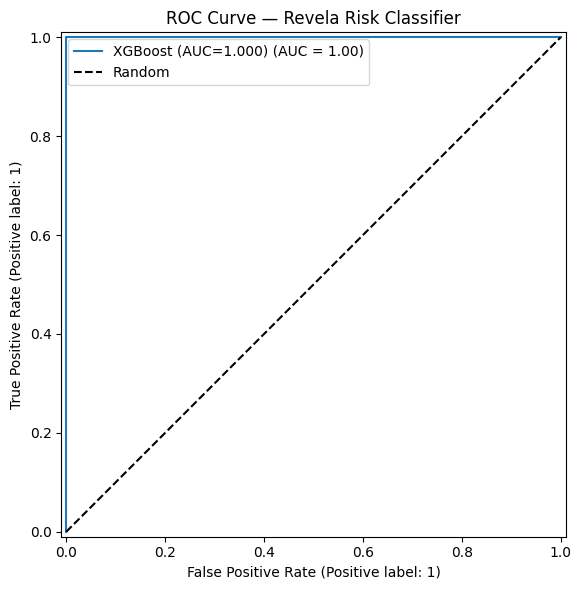

In [12]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name=f'XGBoost (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curve — Revela Risk Classifier')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## 7. Feature importance

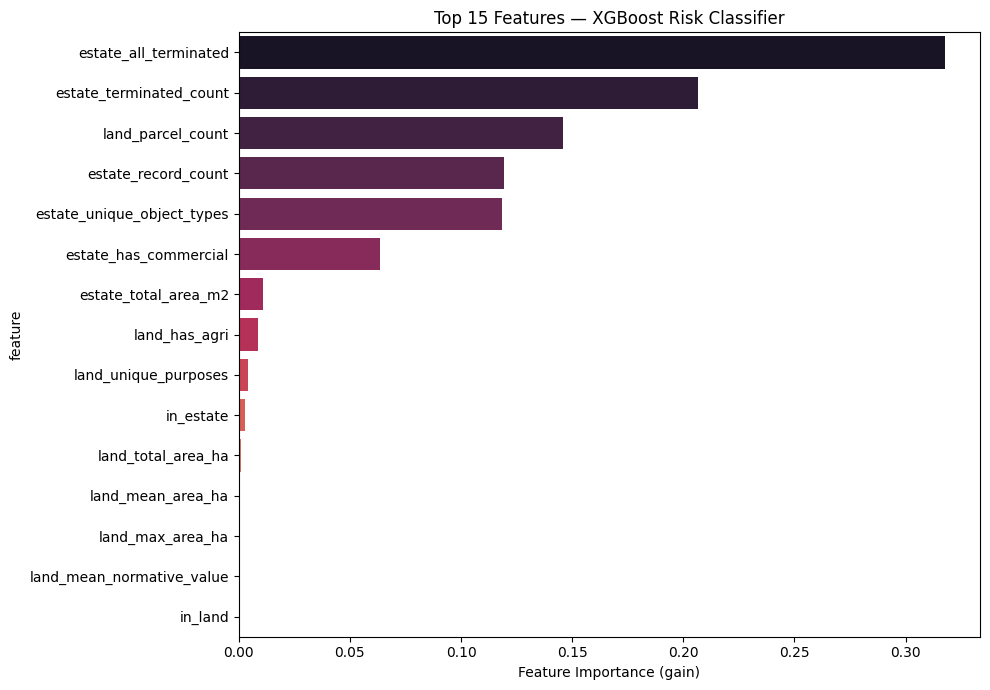

,feature,importance
9,estate_all_terminated,0.317615
8,estate_terminated_count,0.206566
0,land_parcel_count,0.146098
7,estate_record_count,0.119197
11,estate_unique_object_types,0.118540
10,estate_has_commercial,0.063417
12,estate_total_area_m2,0.011035
5,land_has_agri,0.008642
4,land_unique_purposes,0.004125
14,in_estate,0.002882


In [13]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance.head(15), x='importance', y='feature', palette='rocket', ax=ax)
ax.set_title('Top 15 Features — XGBoost Risk Classifier')
ax.set_xlabel('Feature Importance (gain)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

importance.head(15)

## 8. SHAP values (explainability)

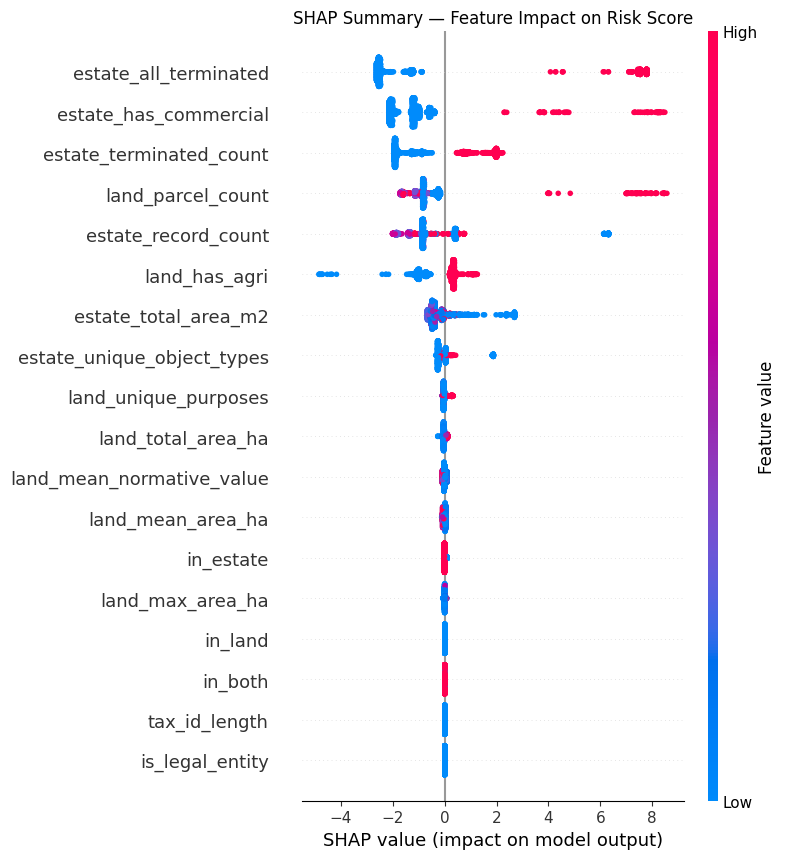

In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary — Feature Impact on Risk Score')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Score all tax IDs and inspect top risks

In [15]:
features['ml_risk_score'] = model.predict_proba(X)[:, 1]

# Join owner names back
owner_map = pd.concat([
    land_valid[['tax_id', 'owner_name']],
    estate_valid[['tax_id', 'owner_name']]
]).dropna().groupby('tax_id')['owner_name'].first().reset_index()

top_risks = features[['tax_id', 'ml_risk_score', 'risk', 'in_land', 'in_estate',
                       'land_parcel_count', 'estate_record_count', 'estate_all_terminated',
                       'land_has_agri', 'estate_has_commercial']] \
    .merge(owner_map, on='tax_id', how='left') \
    .sort_values('ml_risk_score', ascending=False)

print('Top 20 highest ML risk scores:')
top_risks[['tax_id', 'owner_name', 'ml_risk_score', 'risk']].head(20)

Top 20 highest ML risk scores:


,tax_id,owner_name,ml_risk_score,risk
3225,2005917828,Козак Ніна Петрівна,0.999978,1
10421,2933249259,Ніконов Микола Олександрович,0.999977,1
10617,3600534545,Саноцька Олександра Михайлівна,0.999973,1
3604,2539576568,Іваневич Михайло Іванович,0.999972,1
5866,3330367407,Олійчук Ірина Ярославівна,0.999972,1
4287,3390223349,Двойнішнікова Ганна Михайлівна,0.999972,1
10566,3573954536,Чернікова Юлія Сергіївна,0.999972,1
6231,3749101247,Горела Людмила Вадимівна,0.999969,1
10700,1449962649,Колесніченко Олександр Миколайович,0.999969,1
10702,1601773496,Сокіл Володимир Зіновійович,0.999969,1


## 10. Cross-validation (robustness check)

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print(f'5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {cv_scores.round(4)}')

5-fold CV ROC-AUC: 1.0000 ± 0.0000
Fold scores: [1. 1. 1. 1. 1.]


## 11. Save model

In [17]:
model.save_model('revela_risk_model.json')
print('Model saved to revela_risk_model.json')
print(f'Feature columns ({len(feature_cols)}):', feature_cols)

Model saved to revela_risk_model.json
Feature columns (18): ['land_parcel_count', 'land_total_area_ha', 'land_mean_area_ha', 'land_max_area_ha', 'land_unique_purposes', 'land_has_agri', 'land_mean_normative_value', 'estate_record_count', 'estate_terminated_count', 'estate_all_terminated', 'estate_has_commercial', 'estate_unique_object_types', 'estate_total_area_m2', 'in_land', 'in_estate', 'in_both', 'tax_id_length', 'is_legal_entity']
